#### Import Libraries

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score,recall_score,f1_score
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix

##### Loading data and transform to numeric or scale it

In [2]:
df = pd.read_csv("../data/Churn_Modelling.csv")

num_features = ['Age', 'Balance', 'CreditScore', "EstimatedSalary","NumOfProducts","IsActiveMember"]
cat_features = ['Geography', 'Gender']



preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OrdinalEncoder(), cat_features)
    ])
#
X = df[num_features + cat_features]
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Handling class imbalance using SMOTE to oversample minority class (Churned) in training data only via imblearn Pipeline
### Comparing 9 models with balanced class weights and tracking F1, Accuracy, Recall to prioritize churn detection over raw accuracy
### XGBoost additionally uses scale_pos_weight to further penalize missing churned customers during training

In [3]:
from imblearn.pipeline import Pipeline   # ← change sklearn to imblearn
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
import pandas as pd

# scale_pos_weight for XGBoost
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = round(neg / pos, 2)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest":       RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "AdaBoost":            AdaBoostClassifier(random_state=42),
    "Extra Trees":         ExtraTreesClassifier(random_state=42, class_weight='balanced'),
    "Ridge Classifier":    RidgeClassifier(class_weight='balanced'),
    "SGD Classifier":      SGDClassifier(random_state=42, class_weight='balanced'),
    "XGBoost":             XGBClassifier(scale_pos_weight=scale, eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    step_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(k_neighbors=5, random_state=42)),  # ← added
        ('classifier',   model)
    ])

    step_pipeline.fit(X_train, y_train)
    y_pred = step_pipeline.predict(X_test)

    results.append({
        "Model"    : name,
        "F1 Score" : f1_score(y_test, y_pred), 
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Recall"   : round(f1_score(y_test, y_pred, average=None)[1], 4)
    })
    print(f"Finished: {name}")

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
print(results_df)

Finished: Logistic Regression
Finished: Random Forest
Finished: Gradient Boosting
Finished: Decision Tree
Finished: AdaBoost
Finished: Extra Trees
Finished: Ridge Classifier
Finished: SGD Classifier
Finished: XGBoost
                 Model  F1 Score  Accuracy  Recall
2    Gradient Boosting  0.615058    0.8185  0.6151
1        Random Forest  0.595438    0.8315  0.5954
4             AdaBoost  0.579568    0.7860  0.5796
8              XGBoost  0.574861    0.7700  0.5749
5          Extra Trees  0.565806    0.8235  0.5658
6     Ridge Classifier  0.500000    0.7090  0.5000
0  Logistic Regression  0.497436    0.7060  0.4974
7       SGD Classifier  0.476675    0.6915  0.4767
3        Decision Tree  0.475761    0.7675  0.4758


#### Choose best model with best f1 score or fit to data

In [4]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier

# 2. Use ImbPipeline
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(k_neighbors=5, random_state=42)),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

model_pipeline.fit(X_train, y_train)


y_pred = model_pipeline.predict(X_test)

print(classification_report(y_test, y_pred))
print(accuracy_score(y_test,y_pred))
f1_score(y_test,y_pred)

              precision    recall  f1-score   support

           0       0.92      0.85      0.88      1593
           1       0.54      0.71      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000

0.8185


0.6150583244962884

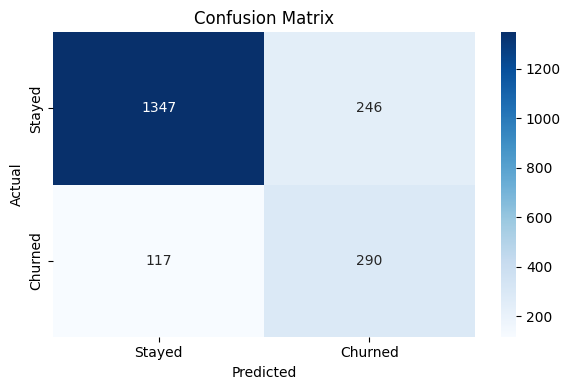

In [5]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

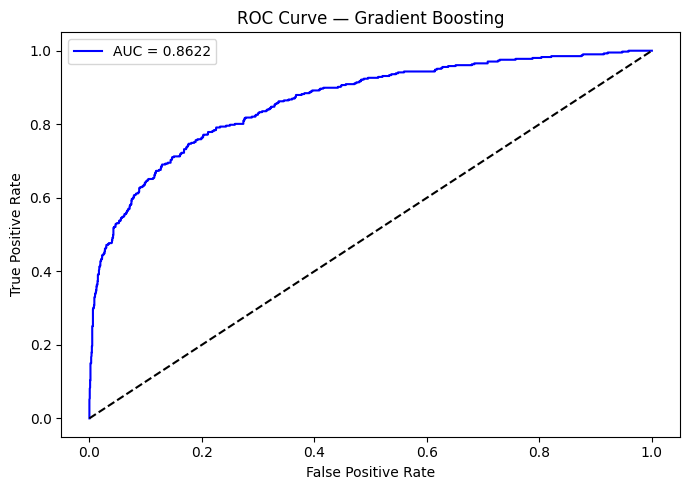

In [6]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob = model_pipeline.predict_proba(X_test)[:, 1]
auc    = roc_auc_score(y_test, y_prob)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='blue')
plt.plot([0,1], [0,1], 'k--')
plt.title('ROC Curve — Gradient Boosting')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
import pickle
with open("../app/modeL/model_pipeline.pkl", "wb") as f:
    pickle.dump(model_pipeline, f)

In [25]:
num_features = ['Age', 'Balance', 'CreditScore', "EstimatedSalary","NumOfProducts","IsActiveMember"]
cat_features = ['Geography', 'Gender']
X  = num_features + cat_features 
X.append("Exited")
df = df[X]
df.to_csv("../data/Cleanind_data.csv")